In [1]:
import os
import time
import math
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from scipy.signal import convolve2d

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
LOGS = OUTPUTS / "logs"

DEBLUR_DIR = DATA_PROCESSED / "deblurred_gopro"
RL_DIR = DEBLUR_DIR / "richardson_lucy"
WIENER_DIR = DEBLUR_DIR / "wiener"

for p in [FIGURES, TABLES, LOGS, DEBLUR_DIR, RL_DIR, WIENER_DIR]:
    p.mkdir(parents=True, exist_ok=True)

gopro_pairs_path = DATA_PROCESSED / "gopro_pairs_metadata.csv"
gopro_pairs_df = pd.read_csv(gopro_pairs_path)

print("Pairs loaded:", len(gopro_pairs_df))
gopro_pairs_df.head()

Pairs loaded: 1029


,filename,blur_path,sharp_path,blur_shape,sharp_shape,blur_lap_var,sharp_lap_var,blur_ratio,blur_level
0,000001.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",13.613243,185.186727,0.073511,high_blur
1,000002.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",44.505477,186.324475,0.238860,low_blur
2,000003.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",37.046103,197.533175,0.187544,medium_blur
3,000004.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",32.943472,190.854369,0.172611,medium_blur
4,000005.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",25.160059,193.846921,0.129793,high_blur


In [3]:
def read_rgb(path):
    img = cv2.imread(str(path))
    if img is None:
        raise ValueError(f"Could not read {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def save_rgb(path, image_rgb):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(path), image_bgr)

def to_float32(img):
    return img.astype(np.float32) / 255.0

def to_uint8(img):
    img = np.clip(img * 255.0, 0, 255)
    return img.astype(np.uint8)

In [4]:
def motion_psf(length=15, angle=0):
    size = max(3, int(length))
    if size % 2 == 0:
        size += 1

    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2

    x1 = center - (length // 2) * math.cos(math.radians(angle))
    y1 = center - (length // 2) * math.sin(math.radians(angle))
    x2 = center + (length // 2) * math.cos(math.radians(angle))
    y2 = center + (length // 2) * math.sin(math.radians(angle))

    cv2.line(
        kernel,
        (int(round(x1)), int(round(y1))),
        (int(round(x2)), int(round(y2))),
        1,
        thickness=1
    )

    s = kernel.sum()
    if s > 0:
        kernel /= s
    return kernel

In [5]:
def motion_psf(length=15, angle=0):
    size = max(3, int(length))
    if size % 2 == 0:
        size += 1

    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2

    x1 = center - (length // 2) * math.cos(math.radians(angle))
    y1 = center - (length // 2) * math.sin(math.radians(angle))
    x2 = center + (length // 2) * math.cos(math.radians(angle))
    y2 = center + (length // 2) * math.sin(math.radians(angle))

    cv2.line(
        kernel,
        (int(round(x1)), int(round(y1))),
        (int(round(x2)), int(round(y2))),
        1,
        thickness=1
    )

    s = kernel.sum()
    if s > 0:
        kernel /= s
    return kernel

In [6]:
def estimate_motion_angle(gray):
    edges = cv2.Canny((gray * 255).astype(np.uint8), 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=80)

    if lines is None:
        return 0.0

    angles = []
    for line in lines[:30]:
        rho, theta = line[0]
        angle = np.degrees(theta) - 90
        angles.append(angle)

    if len(angles) == 0:
        return 0.0

    return float(np.median(angles))

def estimate_kernel_length(blur_lap_var):
    if blur_lap_var < 20:
        return 21
    if blur_lap_var < 50:
        return 17
    if blur_lap_var < 100:
        return 13
    return 9

In [7]:
def wiener_deconvolution_channel(channel, kernel, k=0.01):
    kernel_padded = np.zeros_like(channel, dtype=np.float32)
    kh, kw = kernel.shape
    kernel_padded[:kh, :kw] = kernel
    kernel_padded = np.roll(kernel_padded, -kh // 2, axis=0)
    kernel_padded = np.roll(kernel_padded, -kw // 2, axis=1)

    channel_fft = np.fft.fft2(channel)
    kernel_fft = np.fft.fft2(kernel_padded)

    kernel_fft_conj = np.conj(kernel_fft)
    restored_fft = (kernel_fft_conj / (np.abs(kernel_fft) ** 2 + k)) * channel_fft
    restored = np.fft.ifft2(restored_fft).real
    return np.clip(restored, 0, 1)

def wiener_deconvolution_rgb(image_rgb, kernel, k=0.01):
    image = to_float32(image_rgb)
    restored = np.zeros_like(image, dtype=np.float32)
    for c in range(3):
        restored[:, :, c] = wiener_deconvolution_channel(image[:, :, c], kernel, k=k)
    return to_uint8(restored)

In [8]:
def rgb_to_ycrcb_float(image_rgb):
    img = to_float32(image_rgb)
    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    return ycrcb

def ycrcb_float_to_rgb(ycrcb):
    rgb = cv2.cvtColor(np.clip(ycrcb, 0, 1), cv2.COLOR_YCrCb2RGB)
    return to_uint8(rgb)

def richardson_lucy_luma_rgb(image_rgb, kernel, iterations=6):
    ycrcb = rgb_to_ycrcb_float(image_rgb)
    y = ycrcb[:, :, 0]
    y_restored = richardson_lucy_channel(y, kernel, iterations=iterations)
    ycrcb[:, :, 0] = np.clip(y_restored, 0, 1)
    return ycrcb_float_to_rgb(ycrcb)

In [9]:
def compute_psnr(img_true, img_pred):
    return peak_signal_noise_ratio(img_true, img_pred, data_range=255)

def compute_ssim(img_true, img_pred):
    return structural_similarity(img_true, img_pred, channel_axis=2, data_range=255)

def lap_var_from_rgb(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

In [10]:
sample_n = min(300, len(gopro_pairs_df))
eval_df = gopro_pairs_df.sample(sample_n, random_state=SEED).reset_index(drop=True)

print("Evaluation subset:", len(eval_df))
eval_df.head()

Evaluation subset: 300


,filename,blur_path,sharp_path,blur_shape,sharp_shape,blur_lap_var,sharp_lap_var,blur_ratio,blur_level
0,000291.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",92.953444,419.728245,0.221461,low_blur
1,000734.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",45.254978,366.378675,0.123520,low_blur
2,000262.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",57.597104,346.384915,0.166281,low_blur
3,000108.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",28.676057,110.963763,0.258427,medium_blur
4,000620.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,"(720, 1280)","(720, 1280)",16.376034,152.894041,0.107107,high_blur


In [11]:
def resize_keep_aspect(image_rgb, max_dim=512):
    h, w = image_rgb.shape[:2]
    scale = min(max_dim / max(h, w), 1.0)
    new_w = int(w * scale)
    new_h = int(h * scale)
    if scale == 1.0:
        return image_rgb
    return cv2.resize(image_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

In [13]:
def richardson_lucy_channel(image_channel, kernel, iterations=10):
    image_channel = image_channel.astype(np.float32)
    estimate = np.maximum(image_channel, 1e-6)

    kernel_flip = np.flipud(np.fliplr(kernel))

    for _ in range(iterations):
        conv_estimate = cv2.filter2D(estimate, -1, kernel, borderType=cv2.BORDER_REFLECT)
        relative_blur = image_channel / (conv_estimate + 1e-6)
        estimate *= cv2.filter2D(relative_blur, -1, kernel_flip, borderType=cv2.BORDER_REFLECT)

    return np.clip(estimate, 0, 1)

In [15]:
results = []

sample_n = min(300, len(gopro_pairs_df))
eval_df = gopro_pairs_df.sample(sample_n, random_state=SEED).reset_index(drop=True)

print("Evaluation subset:", len(eval_df))

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    blur_path = row["blur_path"]
    sharp_path = row["sharp_path"]
    filename = row["filename"]

    blur_img_full = read_rgb(blur_path)
    sharp_img_full = read_rgb(sharp_path)

    blur_img = resize_keep_aspect(blur_img_full, max_dim=512)
    sharp_img = resize_keep_aspect(sharp_img_full, max_dim=512)

    blur_gray = cv2.cvtColor(blur_img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    est_angle = estimate_motion_angle(blur_gray)
    est_length = estimate_kernel_length(row["blur_lap_var"])
    kernel = motion_psf(length=est_length, angle=est_angle)

    t0 = time.perf_counter()
    wiener_img = wiener_deconvolution_rgb(blur_img, kernel, k=0.02)
    wiener_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    rl_img = richardson_lucy_luma_rgb(blur_img, kernel, iterations=6)
    rl_time = time.perf_counter() - t0

    save_rgb(WIENER_DIR / filename, wiener_img)
    save_rgb(RL_DIR / filename, rl_img)

    results.append({
        "filename": filename,
        "blur_path": blur_path,
        "sharp_path": sharp_path,
        "blur_level": row["blur_level"],
        "estimated_angle": est_angle,
        "estimated_kernel_length": est_length,

        "blur_psnr": compute_psnr(sharp_img, blur_img),
        "blur_ssim": compute_ssim(sharp_img, blur_img),
        "blur_lap_var": lap_var_from_rgb(blur_img),

        "wiener_path": str(WIENER_DIR / filename),
        "wiener_psnr": compute_psnr(sharp_img, wiener_img),
        "wiener_ssim": compute_ssim(sharp_img, wiener_img),
        "wiener_lap_var": lap_var_from_rgb(wiener_img),
        "wiener_runtime_sec": wiener_time,

        "rl_path": str(RL_DIR / filename),
        "rl_psnr": compute_psnr(sharp_img, rl_img),
        "rl_ssim": compute_ssim(sharp_img, rl_img),
        "rl_lap_var": lap_var_from_rgb(rl_img),
        "rl_runtime_sec": rl_time,

        "eval_height": blur_img.shape[0],
        "eval_width": blur_img.shape[1]
    })

results_df = pd.DataFrame(results)
results_df.head()

Evaluation subset: 300


  0%|          | 0/300 [00:00<?, ?it/s]

,filename,blur_path,sharp_path,blur_level,estimated_angle,estimated_kernel_length,blur_psnr,blur_ssim,blur_lap_var,wiener_path,...,wiener_ssim,wiener_lap_var,wiener_runtime_sec,rl_path,rl_psnr,rl_ssim,rl_lap_var,rl_runtime_sec,eval_height,eval_width
0,000291.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,low_blur,-2.000008,13,30.255340,0.908911,631.758478,C:\Users\User\comp6001_assignment1\data\proces...,...,0.195795,3109.795392,0.201536,C:\Users\User\comp6001_assignment1\data\proces...,22.416222,0.738943,687.801233,0.262281,288,512
1,000734.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,low_blur,2.999992,17,26.233965,0.869980,319.539495,C:\Users\User\comp6001_assignment1\data\proces...,...,0.247886,1950.616639,0.186857,C:\Users\User\comp6001_assignment1\data\proces...,22.440239,0.727094,415.312864,0.283869,288,512
2,000262.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,low_blur,23.499992,13,26.096888,0.830552,337.482071,C:\Users\User\comp6001_assignment1\data\proces...,...,0.314549,2457.424624,0.174202,C:\Users\User\comp6001_assignment1\data\proces...,23.903996,0.752787,473.114253,0.271914,288,512
3,000108.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,medium_blur,-5.500004,17,33.226315,0.960405,248.801226,C:\Users\User\comp6001_assignment1\data\proces...,...,0.220403,1478.550056,0.188154,C:\Users\User\comp6001_assignment1\data\proces...,22.966191,0.755219,366.606879,0.313614,288,512
4,000620.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,high_blur,-9.000008,21,23.177536,0.674087,84.956176,C:\Users\User\comp6001_assignment1\data\proces...,...,0.286938,782.026759,0.167339,C:\Users\User\comp6001_assignment1\data\proces...,21.237091,0.581663,121.789756,0.282800,288,512


In [16]:
results_df = pd.DataFrame(results)
results_df.head()

,filename,blur_path,sharp_path,blur_level,estimated_angle,estimated_kernel_length,blur_psnr,blur_ssim,blur_lap_var,wiener_path,...,wiener_ssim,wiener_lap_var,wiener_runtime_sec,rl_path,rl_psnr,rl_ssim,rl_lap_var,rl_runtime_sec,eval_height,eval_width
0,000291.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,low_blur,-2.000008,13,30.255340,0.908911,631.758478,C:\Users\User\comp6001_assignment1\data\proces...,...,0.195795,3109.795392,0.201536,C:\Users\User\comp6001_assignment1\data\proces...,22.416222,0.738943,687.801233,0.262281,288,512
1,000734.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,low_blur,2.999992,17,26.233965,0.869980,319.539495,C:\Users\User\comp6001_assignment1\data\proces...,...,0.247886,1950.616639,0.186857,C:\Users\User\comp6001_assignment1\data\proces...,22.440239,0.727094,415.312864,0.283869,288,512
2,000262.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,low_blur,23.499992,13,26.096888,0.830552,337.482071,C:\Users\User\comp6001_assignment1\data\proces...,...,0.314549,2457.424624,0.174202,C:\Users\User\comp6001_assignment1\data\proces...,23.903996,0.752787,473.114253,0.271914,288,512
3,000108.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,medium_blur,-5.500004,17,33.226315,0.960405,248.801226,C:\Users\User\comp6001_assignment1\data\proces...,...,0.220403,1478.550056,0.188154,C:\Users\User\comp6001_assignment1\data\proces...,22.966191,0.755219,366.606879,0.313614,288,512
4,000620.png,C:\Users\User\comp6001_assignment1\data\raw\go...,C:\Users\User\comp6001_assignment1\data\raw\go...,high_blur,-9.000008,21,23.177536,0.674087,84.956176,C:\Users\User\comp6001_assignment1\data\proces...,...,0.286938,782.026759,0.167339,C:\Users\User\comp6001_assignment1\data\proces...,21.237091,0.581663,121.789756,0.282800,288,512


In [17]:
metrics_path = TABLES / "gopro_deblurring_results.csv"
results_df.to_csv(metrics_path, index=False)
print(metrics_path)

C:\Users\User\comp6001_assignment1\outputs\tables\gopro_deblurring_results.csv


In [18]:
summary_table = pd.DataFrame({
    "method": ["blurred", "wiener", "richardson_lucy"],
    "mean_psnr": [
        results_df["blur_psnr"].mean(),
        results_df["wiener_psnr"].mean(),
        results_df["rl_psnr"].mean(),
    ],
    "mean_ssim": [
        results_df["blur_ssim"].mean(),
        results_df["wiener_ssim"].mean(),
        results_df["rl_ssim"].mean(),
    ],
    "mean_laplacian_variance": [
        results_df["blur_lap_var"].mean(),
        results_df["wiener_lap_var"].mean(),
        results_df["rl_lap_var"].mean(),
    ],
    "mean_runtime_sec": [
        0.0,
        results_df["wiener_runtime_sec"].mean(),
        results_df["rl_runtime_sec"].mean(),
    ]
})

summary_table

,method,mean_psnr,mean_ssim,mean_laplacian_variance,mean_runtime_sec
0,blurred,27.376671,0.828421,246.526396,0.000000
1,wiener,16.169842,0.291458,1612.577555,0.192737
2,richardson_lucy,22.799273,0.703646,345.827754,0.296825


In [19]:
summary_path = TABLES / "gopro_deblurring_summary.csv"
summary_table.to_csv(summary_path, index=False)
print(summary_path)

C:\Users\User\comp6001_assignment1\outputs\tables\gopro_deblurring_summary.csv


In [20]:
blur_group_summary = results_df.groupby("blur_level").agg({
    "blur_psnr": "mean",
    "blur_ssim": "mean",
    "wiener_psnr": "mean",
    "wiener_ssim": "mean",
    "rl_psnr": "mean",
    "rl_ssim": "mean",
    "wiener_runtime_sec": "mean",
    "rl_runtime_sec": "mean"
}).round(4)

blur_group_summary

,blur_psnr,blur_ssim,wiener_psnr,wiener_ssim,rl_psnr,rl_ssim,wiener_runtime_sec,rl_runtime_sec
blur_level,,,,,,,,
high_blur,25.2143,0.7475,17.5205,0.3413,22.9731,0.6683,0.1926,0.3070
low_blur,29.3719,0.9052,15.1919,0.2564,22.9061,0.7463,0.1927,0.2805
medium_blur,27.9113,0.8461,15.5499,0.2675,22.4715,0.7017,0.1929,0.3017


In [21]:
blur_group_summary_path = TABLES / "gopro_deblurring_by_blur_level.csv"
blur_group_summary.to_csv(blur_group_summary_path)
print(blur_group_summary_path)

C:\Users\User\comp6001_assignment1\outputs\tables\gopro_deblurring_by_blur_level.csv


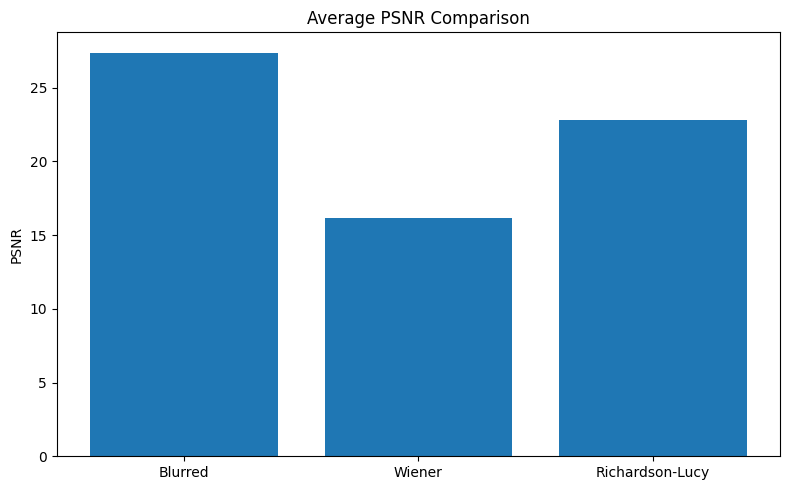

In [22]:
plt.figure(figsize=(8, 5))
x = ["Blurred", "Wiener", "Richardson-Lucy"]
y = [
    results_df["blur_psnr"].mean(),
    results_df["wiener_psnr"].mean(),
    results_df["rl_psnr"].mean()
]
plt.bar(x, y)
plt.ylabel("PSNR")
plt.title("Average PSNR Comparison")
plt.tight_layout()
plt.savefig(FIGURES / "avg_psnr_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

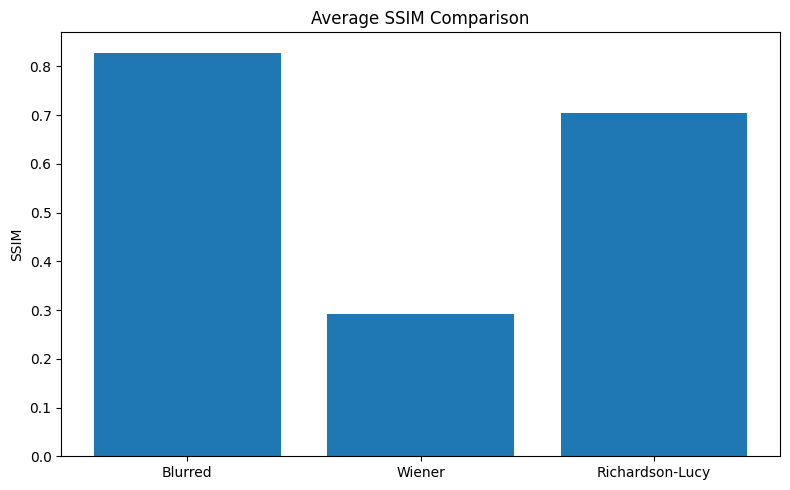

In [23]:
plt.figure(figsize=(8, 5))
x = ["Blurred", "Wiener", "Richardson-Lucy"]
y = [
    results_df["blur_ssim"].mean(),
    results_df["wiener_ssim"].mean(),
    results_df["rl_ssim"].mean()
]
plt.bar(x, y)
plt.ylabel("SSIM")
plt.title("Average SSIM Comparison")
plt.tight_layout()
plt.savefig(FIGURES / "avg_ssim_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

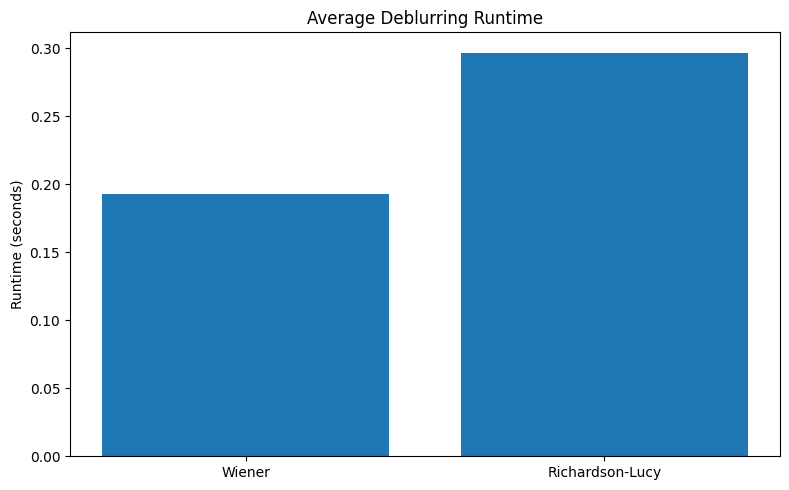

In [24]:
plt.figure(figsize=(8, 5))
x = ["Wiener", "Richardson-Lucy"]
y = [
    results_df["wiener_runtime_sec"].mean(),
    results_df["rl_runtime_sec"].mean()
]
plt.bar(x, y)
plt.ylabel("Runtime (seconds)")
plt.title("Average Deblurring Runtime")
plt.tight_layout()
plt.savefig(FIGURES / "avg_runtime_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [25]:
best_examples = results_df.sort_values("rl_psnr", ascending=False).head(3)
worst_examples = results_df.sort_values("rl_psnr", ascending=True).head(3)

best_examples[["filename", "blur_psnr", "wiener_psnr", "rl_psnr", "blur_ssim", "wiener_ssim", "rl_ssim"]]

,filename,blur_psnr,wiener_psnr,rl_psnr,blur_ssim,wiener_ssim,rl_ssim
232,000646.png,30.648971,19.267322,27.257306,0.907244,0.376320,0.819527
60,000648.png,28.392948,20.954551,27.092442,0.799778,0.460098,0.767061
129,002527.png,26.476462,22.262553,26.943369,0.732247,0.488644,0.730141


In [26]:
def show_restoration_comparison(row):
    blur_img = read_rgb(row["blur_path"])
    sharp_img = read_rgb(row["sharp_path"])
    wiener_img = read_rgb(row["wiener_path"])
    rl_img = read_rgb(row["rl_path"])

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(blur_img)
    axes[0].set_title(f"Blurred\nPSNR={row['blur_psnr']:.2f}, SSIM={row['blur_ssim']:.3f}")
    axes[0].axis("off")

    axes[1].imshow(wiener_img)
    axes[1].set_title(f"Wiener\nPSNR={row['wiener_psnr']:.2f}, SSIM={row['wiener_ssim']:.3f}")
    axes[1].axis("off")

    axes[2].imshow(rl_img)
    axes[2].set_title(f"Richardson-Lucy\nPSNR={row['rl_psnr']:.2f}, SSIM={row['rl_ssim']:.3f}")
    axes[2].axis("off")

    axes[3].imshow(sharp_img)
    axes[3].set_title("Sharp Reference")
    axes[3].axis("off")

    plt.suptitle(f"{row['filename']} | {row['blur_level']}")
    plt.tight_layout()
    plt.show()

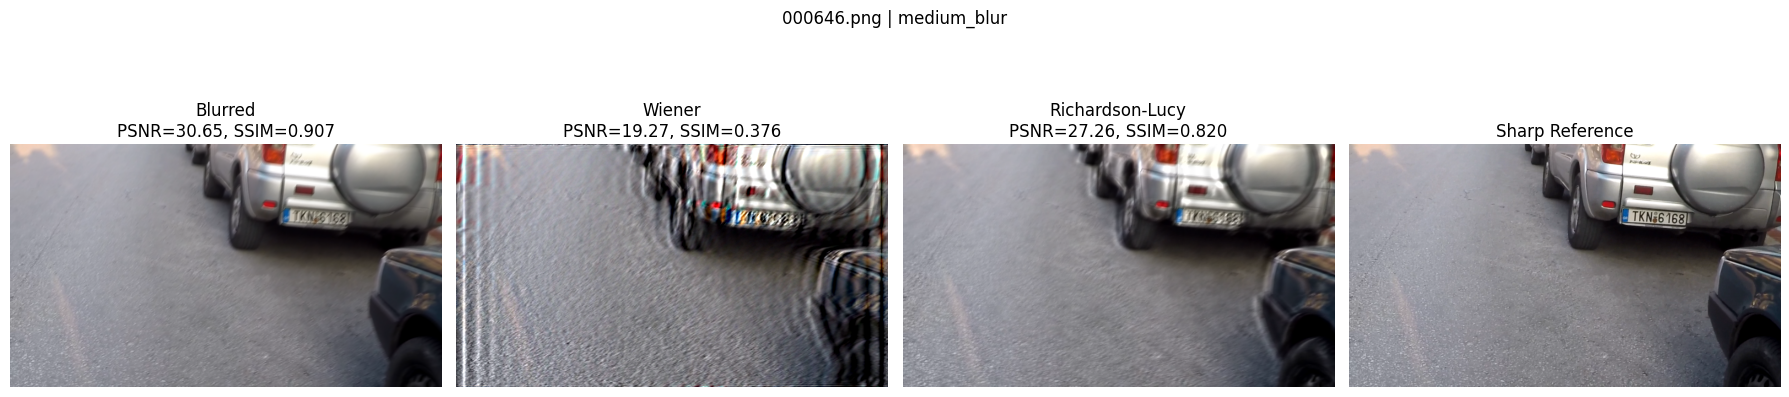

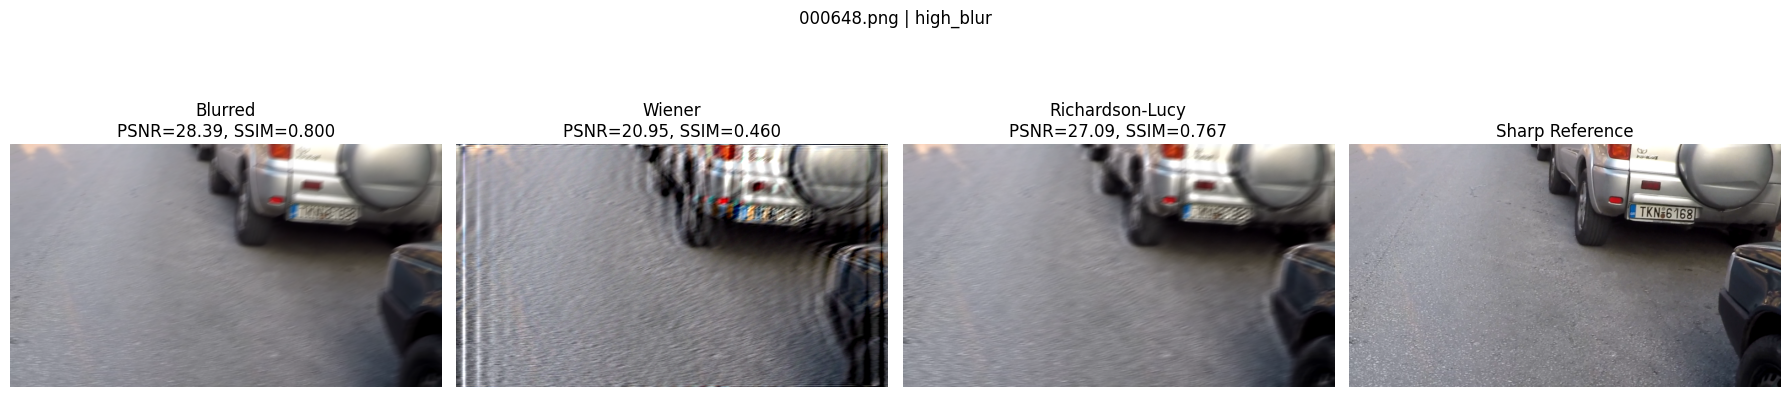

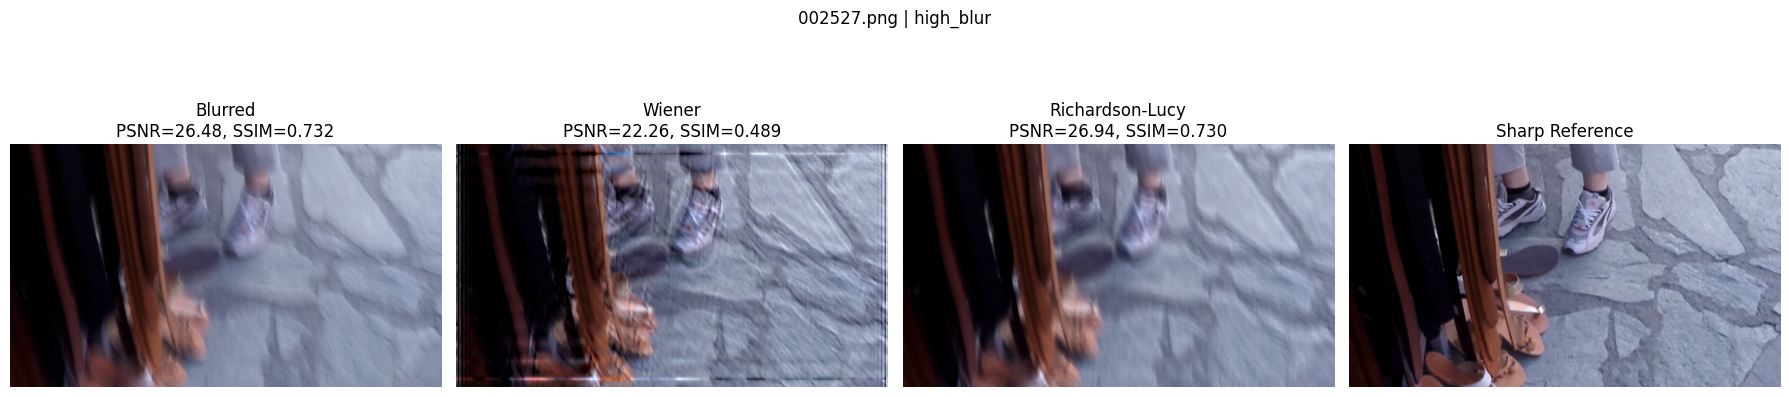

In [27]:
for _, row in best_examples.iterrows():
    show_restoration_comparison(row)

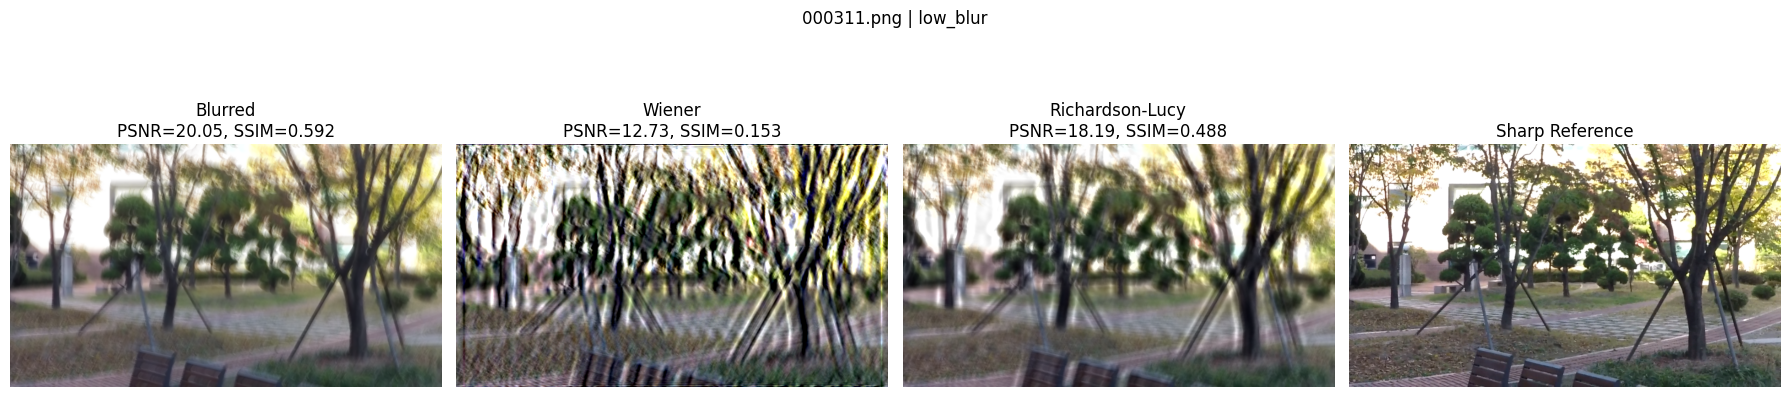

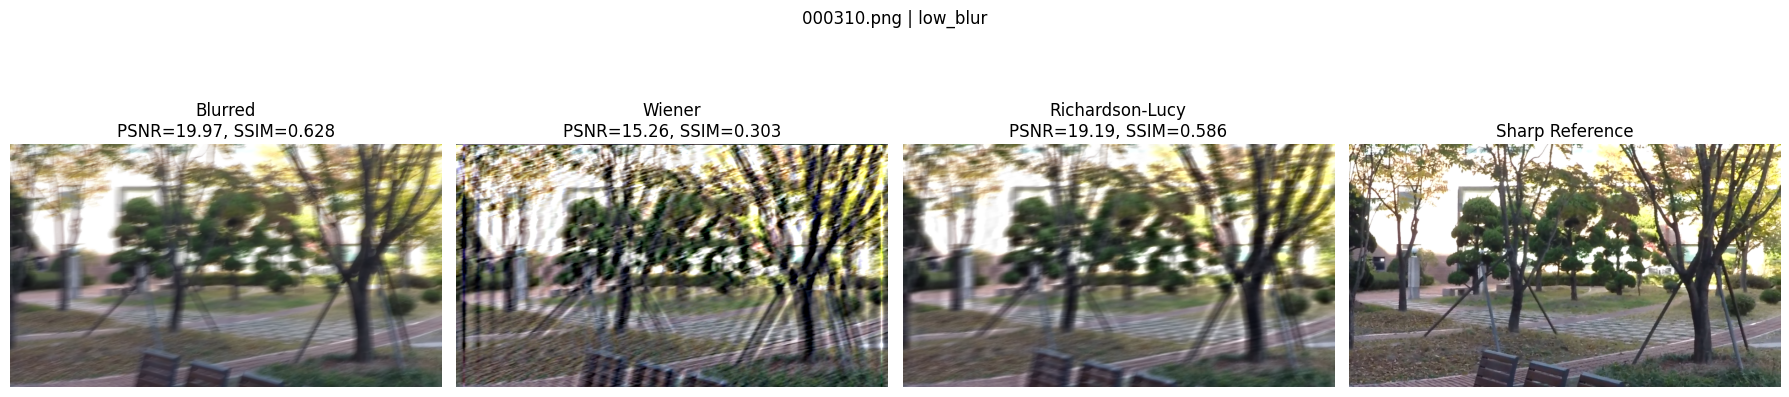

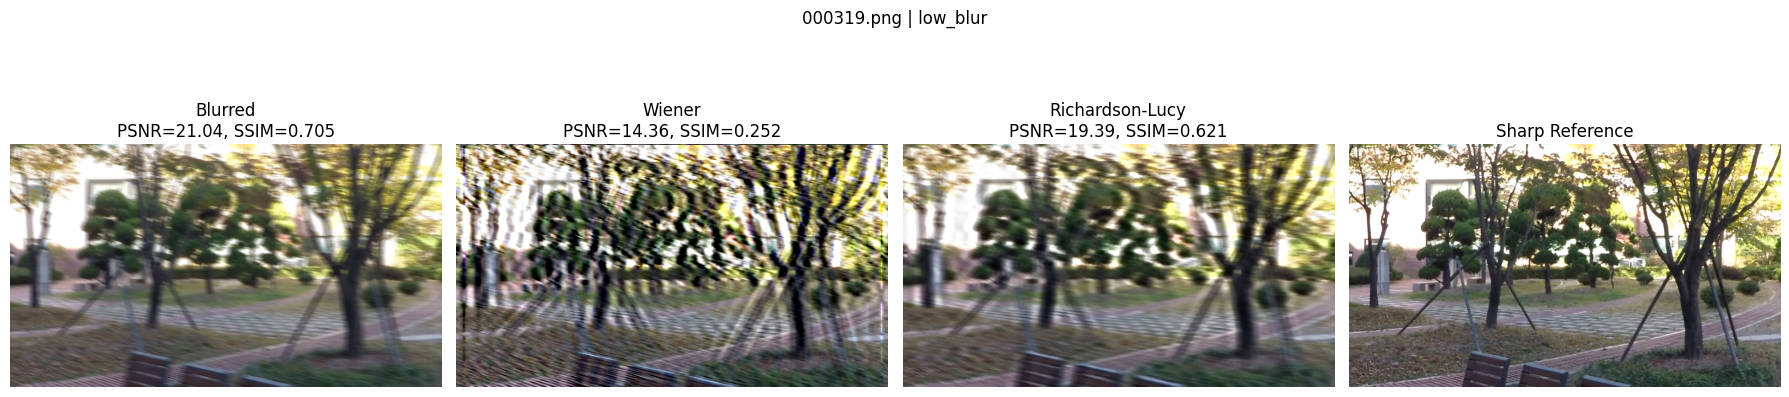

In [28]:
for _, row in worst_examples.iterrows():
    show_restoration_comparison(row)

In [29]:
results_df["wiener_psnr_gain"] = results_df["wiener_psnr"] - results_df["blur_psnr"]
results_df["rl_psnr_gain"] = results_df["rl_psnr"] - results_df["blur_psnr"]
results_df["wiener_ssim_gain"] = results_df["wiener_ssim"] - results_df["blur_ssim"]
results_df["rl_ssim_gain"] = results_df["rl_ssim"] - results_df["blur_ssim"]

gain_summary = pd.DataFrame({
    "method": ["wiener", "richardson_lucy"],
    "avg_psnr_gain": [
        results_df["wiener_psnr_gain"].mean(),
        results_df["rl_psnr_gain"].mean()
    ],
    "avg_ssim_gain": [
        results_df["wiener_ssim_gain"].mean(),
        results_df["rl_ssim_gain"].mean()
    ]
})

gain_summary

,method,avg_psnr_gain,avg_ssim_gain
0,wiener,-11.206829,-0.536963
1,richardson_lucy,-4.577397,-0.124775


In [30]:
gain_summary_path = TABLES / "gopro_restoration_gain_summary.csv"
gain_summary.to_csv(gain_summary_path, index=False)
print(gain_summary_path)

C:\Users\User\comp6001_assignment1\outputs\tables\gopro_restoration_gain_summary.csv


In [31]:
top_rl_df = results_df.sort_values("rl_psnr_gain", ascending=False).head(10)
low_rl_df = results_df.sort_values("rl_psnr_gain", ascending=True).head(10)

display(top_rl_df[["filename", "blur_level", "blur_psnr", "rl_psnr", "rl_psnr_gain", "rl_ssim_gain"]])
display(low_rl_df[["filename", "blur_level", "blur_psnr", "rl_psnr", "rl_psnr_gain", "rl_ssim_gain"]])

,filename,blur_level,blur_psnr,rl_psnr,rl_psnr_gain,rl_ssim_gain
297,000615.png,high_blur,20.880764,21.828254,0.947490,0.048438
296,000334.png,high_blur,23.401462,24.239002,0.837540,0.005466
79,000245.png,high_blur,23.255793,24.080397,0.824604,0.054342
84,000606.png,high_blur,20.514399,21.077268,0.562869,0.034370
230,000560.png,high_blur,25.341885,25.828444,0.486559,0.021339
129,002527.png,high_blur,26.476462,26.943369,0.466906,-0.002106
298,002509.png,high_blur,25.347429,25.788195,0.440765,0.020264
283,000308.png,low_blur,19.203448,19.632961,0.429512,0.015210
262,000250.png,high_blur,23.378332,23.697204,0.318872,0.016580
103,002500.png,high_blur,24.999263,25.176928,0.177665,0.003809


,filename,blur_level,blur_psnr,rl_psnr,rl_psnr_gain,rl_ssim_gain
34,000102.png,low_blur,37.996354,22.954708,-15.041646,-0.222206
121,000101.png,medium_blur,36.396494,23.518792,-12.877701,-0.206831
286,000105.png,medium_blur,35.408342,23.070006,-12.338336,-0.206743
241,000166.png,low_blur,34.382201,22.203030,-12.179171,-0.284292
158,000121.png,low_blur,34.210431,22.046464,-12.163967,-0.266102
285,002175.png,low_blur,36.834642,24.784915,-12.049727,-0.172808
243,000179.png,medium_blur,34.916233,22.992905,-11.923327,-0.244351
249,002179.png,low_blur,36.133347,24.245969,-11.887378,-0.186262
155,000107.png,medium_blur,34.836215,23.140985,-11.695230,-0.205444
239,001032.png,low_blur,34.812455,23.264122,-11.548333,-0.214918


In [33]:
chosen_method = (
    "richardson_lucy" 
    if results_df["rl_psnr"].mean() > results_df["wiener_psnr"].mean() 
    else "wiener")
print("Chosen restored domain for downstream tasks:", chosen_method)

Chosen restored domain for downstream tasks: richardson_lucy


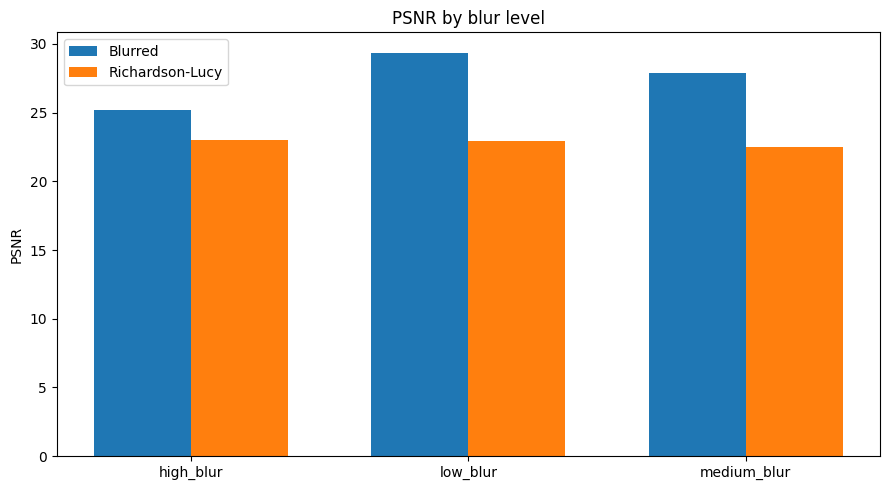

In [34]:
blur_group_summary_plot = blur_group_summary.reset_index()
plt.figure(figsize=(9, 5))
x = np.arange(len(blur_group_summary_plot["blur_level"]))
width = 0.35
plt.bar(x - width/2, blur_group_summary_plot["blur_psnr"], width,
label="Blurred")
plt.bar(x + width/2, blur_group_summary_plot["rl_psnr"], width,
label="Richardson-Lucy")
plt.xticks(x, blur_group_summary_plot["blur_level"])
plt.ylabel("PSNR")
plt.title("PSNR by blur level")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
results_df["rl_psnr_gain"] = results_df["rl_psnr"] - results_df["blur_psnr"]
failure_cases = results_df.sort_values("rl_psnr_gain").head(10)[[
"filename",
"blur_level",
"blur_psnr",
"rl_psnr",
"rl_psnr_gain",
"blur_ssim",
"rl_ssim",
"rl_runtime_sec"
]]
failure_cases.to_csv(TABLES / "restoration_failure_cases.csv", index=False)
failure_cases

,filename,blur_level,blur_psnr,rl_psnr,rl_psnr_gain,blur_ssim,rl_ssim,rl_runtime_sec
34,000102.png,low_blur,37.996354,22.954708,-15.041646,0.978959,0.756754,0.320556
121,000101.png,medium_blur,36.396494,23.518792,-12.877701,0.974442,0.767612,0.271223
286,000105.png,medium_blur,35.408342,23.070006,-12.338336,0.971478,0.764735,0.293288
241,000166.png,low_blur,34.382201,22.203030,-12.179171,0.969438,0.685146,0.280070
158,000121.png,low_blur,34.210431,22.046464,-12.163967,0.967431,0.701328,0.284014
285,002175.png,low_blur,36.834642,24.784915,-12.049727,0.977519,0.804711,0.313697
243,000179.png,medium_blur,34.916233,22.992905,-11.923327,0.968950,0.724599,0.264743
249,002179.png,low_blur,36.133347,24.245969,-11.887378,0.971727,0.785465,0.282792
155,000107.png,medium_blur,34.836215,23.140985,-11.695230,0.969364,0.763920,0.315999
239,001032.png,low_blur,34.812455,23.264122,-11.548333,0.978450,0.763532,0.304050


In [36]:
restoration_log = {
    "num_eval_images": int(len(results_df)),
    "avg_blurred_psnr": float(results_df["blur_psnr"].mean()),
    "avg_wiener_psnr": float(results_df["wiener_psnr"].mean()),
    "avg_rl_psnr": float(results_df["rl_psnr"].mean()),
    "avg_blurred_ssim": float(results_df["blur_ssim"].mean()),
    "avg_wiener_ssim": float(results_df["wiener_ssim"].mean()),
    "avg_rl_ssim": float(results_df["rl_ssim"].mean()),
    "avg_wiener_runtime_sec": float(results_df["wiener_runtime_sec"].mean()),
    "avg_rl_runtime_sec": float(results_df["rl_runtime_sec"].mean())
}

restoration_log

{'num_eval_images': 300,
 'avg_blurred_psnr': 27.376670789146022,
 'avg_wiener_psnr': 16.16984194810039,
 'avg_rl_psnr': 22.799273426949433,
 'avg_blurred_ssim': 0.8284209185086252,
 'avg_wiener_ssim': 0.291457848699366,
 'avg_rl_ssim': 0.7036463812384622,
 'avg_wiener_runtime_sec': 0.19273708833331815,
 'avg_rl_runtime_sec': 0.296825396333373}

In [37]:
import json

with open(LOGS / "deblurring_summary.json", "w") as f:
    json.dump(restoration_log, f, indent=2)

print(LOGS / "deblurring_summary.json")

C:\Users\User\comp6001_assignment1\outputs\logs\deblurring_summary.json
